# starfold on a real chemo-dynamical stellar sample

This optional tutorial applies `starfold` to an 8-D chemo-dynamical feature
vector for 9 242 Milky Way stars. The data ship with the repository at
`docs/data/stellar_chemokinematics_apogee_dr19.parquet` (zstd-compressed
parquet, ~0.5 MB) so the notebook runs offline with no survey download.

| kind | features |
|---|---|
| chemistry | `fe_h`, `alpha_m`, `mg_fe` |
| kinematics | `J_R`, `J_z`, `L_z`, `ecc`, `E` |

Chemistry comes *directly* from APOGEE DR19 ASPCAP atmospheric abundances
([Abdurro'uf et al. 2022](https://doi.org/10.3847/1538-4365/ac4414)): `fe_h`
= `FE_H_ATM`, `alpha_m` = `ALPHA_M_ATM`, and `mg_fe` = `MG_H_ATM` -
`FE_H_ATM`. Actions, energy, and eccentricity come from `galpy` orbit
integration ([Bovy 2015](https://doi.org/10.1088/0067-0049/216/2/29)) in
the `McMillan17` potential using Gaia DR3 astrometry. See
`docs/data/stellar_chemokinematics_apogee_dr19.provenance.md` for the full
pipeline, citations, and SHA-256.

This mirrors the chemo-dynamical space explored in Neitzel et al. (2025) §3
minus the age axis. The feature *choice* is the user's, not `starfold`'s:
the package takes any numeric `(n_samples, n_features)` array.

**GPU path.** If RAPIDS `cuml` is importable the pipeline runs UMAP and
HDBSCAN on the GPU (`engine="auto"`); on CPU-only hardware it falls back
to `umap-learn` and `hdbscan` automatically. At N = 9 242 the run takes
a few seconds on either path.

The bundled file is a convenience for running the tutorial offline. Do
not use it for scientific work -- rebuild from the original surveys for
anything that needs to be citable.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Memory

import starfold as sf

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("cache") / "astro_dr19"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
_MEMORY = Memory(location=str(CACHE_DIR), verbose=0)


@_MEMORY.cache
def _cached_fit(
    X: np.ndarray,
    *,
    umap_kwargs: dict[str, Any],
    hdbscan_optuna_trials: int,
    mcs_range: tuple[int, int],
    ms_range: tuple[int, int],
    engine: str,
    skip_noise_baseline: bool,
    random_state: int,
) -> sf.PipelineResult:
    """Input-content + config-aware cached pipeline fit.

    joblib.Memory hashes every argument (array bytes included), so any
    change to ``X`` or to any kwarg invalidates the entry automatically.
    """
    pipeline = sf.UnsupervisedPipeline(
        umap_kwargs=umap_kwargs,
        hdbscan_optuna_trials=hdbscan_optuna_trials,
        mcs_range=mcs_range,
        ms_range=ms_range,
        engine=engine,
        skip_noise_baseline=skip_noise_baseline,
        random_state=random_state,
    )
    return pipeline.fit(X)


plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "image.cmap": "viridis",
})

LATEX_LABELS = {
    "fe_h":    r"$[\mathrm{Fe/H}]$",
    "mg_fe":   r"$[\mathrm{Mg/Fe}]$",
    "alpha_m": r"$[\alpha/\mathrm{M}]$",
    "J_R":     r"$J_R\;[\mathrm{kpc\,km\,s^{-1}}]$",
    "J_z":     r"$J_z\;[\mathrm{kpc\,km\,s^{-1}}]$",
    "L_z":     r"$L_z\;[\mathrm{kpc\,km\,s^{-1}}]$",
    "ecc":     r"eccentricity $e$",
    "E":       r"$E\;[(\mathrm{km\,s^{-1}})^2]$",
}
CLUSTER_CMAP_NAME = "tab10"
OUTLIER_COLOUR = "0.75"

print(f"cuml importable: {sf.cuml_is_importable()}")
print(f"cache dir      : {CACHE_DIR.resolve()}")

cuml importable: True
cache dir      : /home/aneitzel/projects/starfold/docs/cache/astro_dr19


## 1. Locate the bundled parquet

The file lives at `docs/data/stellar_chemokinematics_apogee_dr19.parquet`
relative to the repo root. We try the notebook's sibling `data/` directory
first, then walk up looking for `docs/data/`, and finally honour
`STARFOLD_TUTORIAL_PARQUET` for users who want to point at a custom path.

In [2]:
DATA_FILE = "stellar_chemokinematics_apogee_dr19.parquet"


def _find_parquet() -> Path:
    env = os.environ.get("STARFOLD_TUTORIAL_PARQUET")
    if env:
        p = Path(env).expanduser().resolve()
        if p.exists():
            return p
    here = Path.cwd().resolve()
    sibling = here / "data" / DATA_FILE
    if sibling.exists():
        return sibling
    for base in (here, *here.parents):
        candidate = base / "docs" / "data" / DATA_FILE
        if candidate.exists():
            return candidate
    msg = (
        f"{DATA_FILE} not found. Run the notebook from inside the starfold "
        "repo, or set STARFOLD_TUTORIAL_PARQUET to an explicit path."
    )
    raise FileNotFoundError(msg)


parquet_path = _find_parquet()
print(f"using {parquet_path}  ({parquet_path.stat().st_size / 1e6:.2f} MB)")

using /home/aneitzel/projects/starfold/docs/data/stellar_chemokinematics_apogee_dr19.parquet  (0.47 MB)


## 2. Assemble the feature matrix

The bundled file is already NaN-free by construction (see the build gates
in the provenance doc); the `isfinite` pass below is belt-and-braces so
the tutorial still works if you swap in your own parquet via
`STARFOLD_TUTORIAL_PARQUET`. At N = 9 242 we just use the whole sample.

In [3]:
FEATURES = ["fe_h", "alpha_m", "mg_fe", "J_R", "J_z", "L_z", "ecc", "E"]
df = pd.read_parquet(parquet_path, columns=["source_id", *FEATURES])
mask = np.isfinite(df[FEATURES].to_numpy()).all(axis=1)
sample = df.loc[mask].reset_index(drop=True)
X = sample[FEATURES].to_numpy(dtype=np.float64)
print(f"X shape = {X.shape}")

X shape = (9242, 8)

## 3. Run the pipeline (cached)

Paper-ish UMAP defaults (`n_neighbors=30`, `min_dist=0.0`). `engine="auto"`
picks the GPU when cuml is importable and falls back silently otherwise.

The fit is wrapped in a `joblib.Memory` cache keyed by `X`'s bytes and
every hyperparameter we pass: identical arguments hit the cache and
skip the UMAP + Optuna search entirely; changing any of them
invalidates the entry automatically. Cache lives at `cache/astro_dr19/`.

The noise baseline is skipped here for speed -- it costs
`n_realisations` full UMAP+HDBSCAN fits, which is the right price for
publication but overkill for a tutorial. Set `skip_noise_baseline=False`
and bump `noise_baseline_kwargs={"n_realisations": 1000}` to reproduce
the paper's 3-sigma gate.

In [4]:
import time

fit_kwargs = dict(
    umap_kwargs={"n_neighbors": 30, "min_dist": 0.0, "n_epochs": 1000},
    hdbscan_optuna_trials=60,
    mcs_range=(50, 2000),
    ms_range=(5, 50),
    engine="auto",
    skip_noise_baseline=True,
    random_state=0,
)

t0 = time.perf_counter()
result = _cached_fit(X, **fit_kwargs)
dt = time.perf_counter() - t0
print(f"fit took {dt:.1f}s  (cache dir: {CACHE_DIR.resolve()})")
print(result.summary())

[2026-04-21 07:14:58.453] [CUML] [info] build_algo set to brute_force_knn because random_state is given


fit took 55.2s  (cache dir: /home/aneitzel/projects/starfold/docs/cache/astro_dr19)
starfold pipeline result
--------------------------------
n_samples        9242
n_clusters       2
n_outliers       32  (0.3%)
trustworthiness  0.9639
best_params      {'min_cluster_size': 462, 'min_samples': 21}
persistence      [0.544 0.265]


## 4. Embedding, Optuna history, and parameter importance

Three diagnostic panels:

* **left** -- the 2-D UMAP embedding coloured by HDBSCAN label (outliers
  grey),
* **middle** -- the Optuna objective (sum of cluster persistences) over
  trials,
* **right** -- TPE's estimate of which hyperparameter mattered.

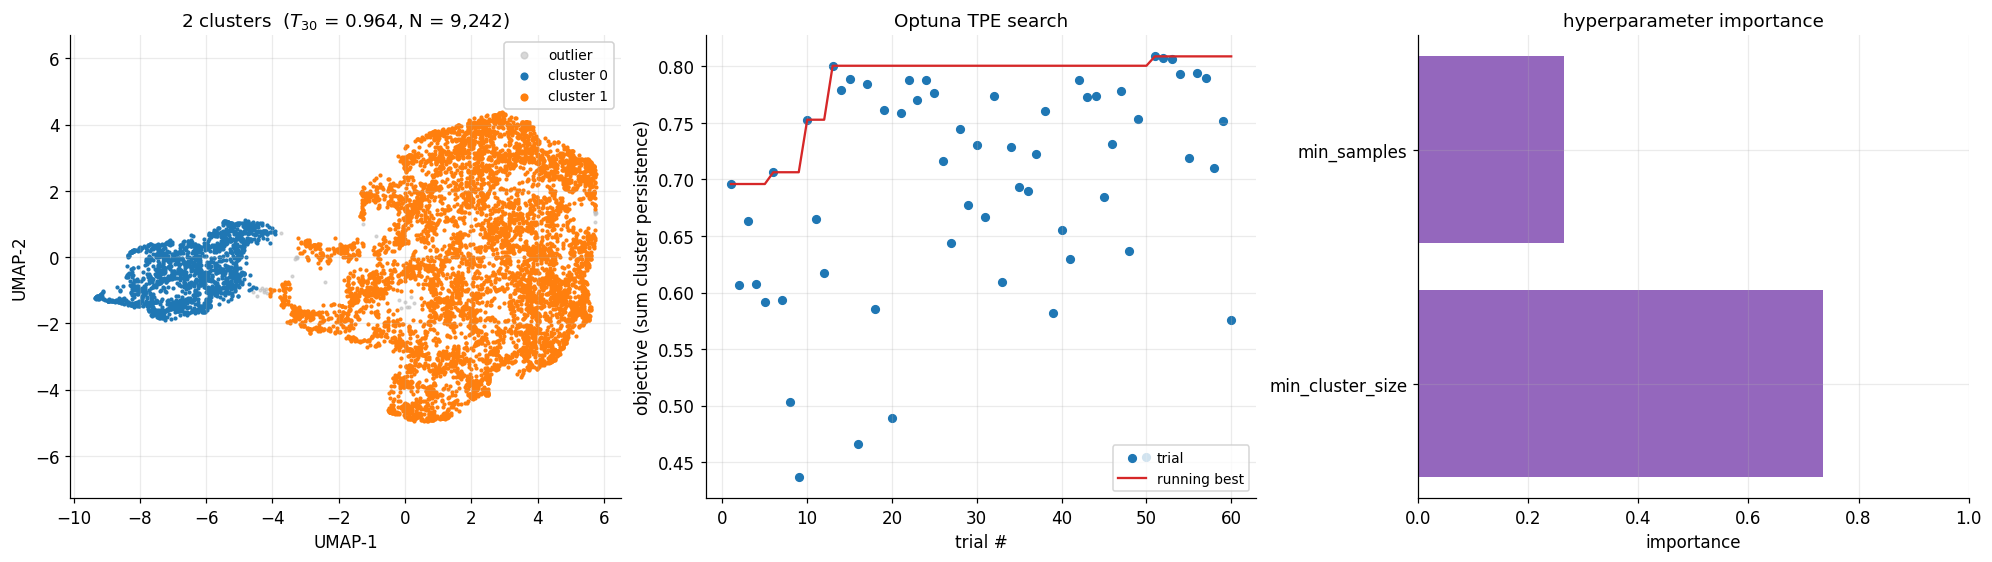

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
sf.plot_embedding(
    result.embedding, result.labels,
    ax=axes[0], point_size=3.0,
    outlier_color=OUTLIER_COLOUR, cmap=CLUSTER_CMAP_NAME,
)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
axes[0].set_title(
    f"{result.n_clusters} clusters  "
    f"($T_{{{int(fit_kwargs['umap_kwargs']['n_neighbors'])}}}$ = "
    f"{result.trustworthiness:.3f}, N = {len(X):,})"
)
axes[0].legend(loc="best", markerscale=2.5, framealpha=0.9)

sf.plot_optuna_history(result.search.study, ax=axes[1])
axes[1].set_title("Optuna TPE search")

sf.plot_optuna_param_importance(result.search.study, ax=axes[2])
axes[2].set_title("hyperparameter importance")

fig.savefig(FIGURE_DIR / "astro_overview.png")
plt.show()

## 5. Chemo-dynamical tomography

The fun part. Colouring the UMAP embedding by each original physical
feature shows what the unsupervised representation has captured. Smooth
gradients in a feature mean UMAP has arranged the manifold along that
axis; sharp discontinuities at cluster boundaries mean the clusters
differ in that feature. Colour scales are clipped to the 2nd-98th
percentile per panel so outliers do not wash out the dynamic range.

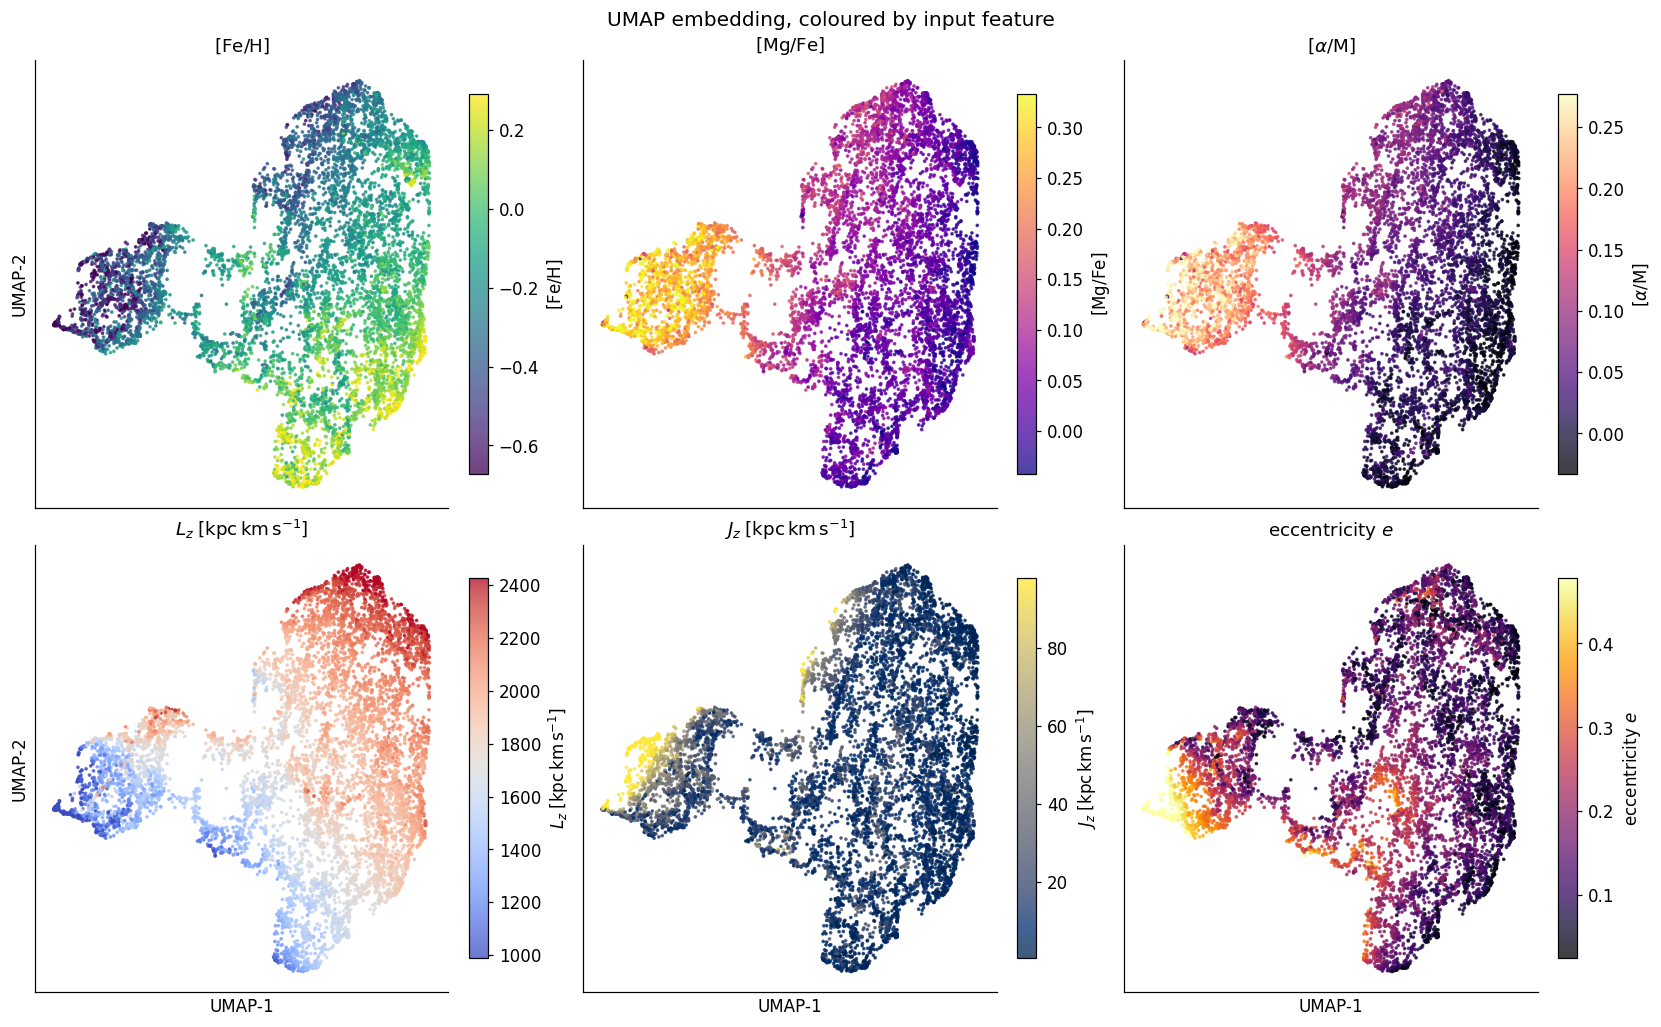

In [6]:
tomo_panels = [
    ("fe_h",    "viridis"),
    ("mg_fe",   "plasma"),
    ("alpha_m", "magma"),
    ("L_z",     "coolwarm"),
    ("J_z",     "cividis"),
    ("ecc",     "inferno"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (col, cmap_name) in zip(axes.flat, tomo_panels, strict=True):
    vals = sample[col].to_numpy()
    vmin, vmax = np.quantile(vals, [0.02, 0.98])
    sc = ax.scatter(
        result.embedding[:, 0], result.embedding[:, 1],
        c=vals, cmap=cmap_name, vmin=vmin, vmax=vmax,
        s=2.0, alpha=0.75, rasterized=True,
    )
    cb = fig.colorbar(sc, ax=ax, shrink=0.85)
    cb.set_label(LATEX_LABELS[col])
    ax.set_title(LATEX_LABELS[col])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
for ax in axes[-1, :]:
    ax.set_xlabel("UMAP-1")
for ax in axes[:, 0]:
    ax.set_ylabel("UMAP-2")
fig.suptitle("UMAP embedding, coloured by input feature", y=1.02)
fig.savefig(FIGURE_DIR / "astro_tomography.png")
plt.show()

## 6. Cluster medians in physical coordinates

Per-cluster median chemistry and dynamics. This is the table you read to
work out which cluster looks like which Galactic component: low
`[Fe/H]` + high `[Mg/Fe]` + low `L_z` is halo-like, high `L_z` + low
eccentricity is disk-like.

In [7]:
rows = []
for label in np.unique(result.labels):
    lab_mask = result.labels == label
    rec = {
        "cluster": "outliers" if label == -1 else int(label),
        "n": int(lab_mask.sum()),
    }
    for f in FEATURES:
        rec[f] = float(np.median(sample.loc[lab_mask, f]))
    rows.append(rec)
medians = pd.DataFrame(rows).set_index("cluster")
medians

,n,fe_h,alpha_m,mg_fe,J_R,J_z,L_z,ecc,E
cluster,,,,,,,,,
outliers,32,-0.173386,0.105646,0.141173,30.303108,13.349757,1662.406616,0.162509,-160903.15625
0,1818,-0.417481,0.222016,0.272921,81.404388,34.637756,1463.617188,0.263651,-163772.31250
1,7392,-0.079556,0.028724,0.043628,23.845367,8.914577,1911.620361,0.131571,-154656.31250


## 7. Chemical abundance plane by cluster

[Mg/Fe] vs [Fe/H] is the canonical chemical discriminator for Galactic
populations. Overplotting clusters on this plane shows whether starfold
has separated a low-alpha disk sequence from a high-alpha halo/thick-disk
sequence without being told about chemistry explicitly.

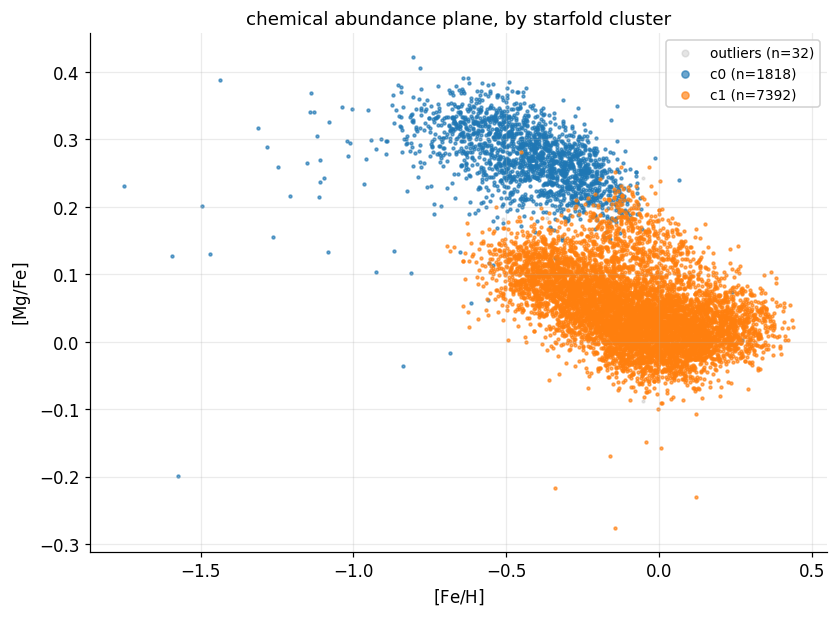

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
out = result.labels == -1
uniq = [int(lab) for lab in np.unique(result.labels) if lab != -1]
cmap = plt.get_cmap(CLUSTER_CMAP_NAME)

ax.scatter(
    sample.loc[out, "fe_h"], sample.loc[out, "mg_fe"],
    c=OUTLIER_COLOUR, s=3.0, alpha=0.4,
    label=f"outliers (n={int(out.sum())})", rasterized=True,
)
for i, lab in enumerate(uniq):
    lab_mask = result.labels == lab
    ax.scatter(
        sample.loc[lab_mask, "fe_h"], sample.loc[lab_mask, "mg_fe"],
        s=3.5, alpha=0.65, color=cmap(i),
        label=f"c{lab} (n={int(lab_mask.sum())})", rasterized=True,
    )
ax.set_xlabel(LATEX_LABELS["fe_h"])
ax.set_ylabel(LATEX_LABELS["mg_fe"])
ax.set_title(r"chemical abundance plane, by starfold cluster")
ax.legend(markerscale=2.5, loc="upper right", framealpha=0.9)
fig.savefig(FIGURE_DIR / "astro_chem_plane.png")
plt.show()

## 8. Action-space Toomre-like diagram

`L_z` vs the non-circular action sum `J_R + J_z`, coloured by cluster.
This is the action-space analogue of the classic Toomre velocity
diagram: high `L_z` + low non-circular action = disk; low / negative
`L_z` + high non-circular action = halo. We plot `J_R + J_z` directly
(in `kpc km s^{-1}`) rather than taking a square root, since the
relevant dynamical quantity in action space is the sum itself.

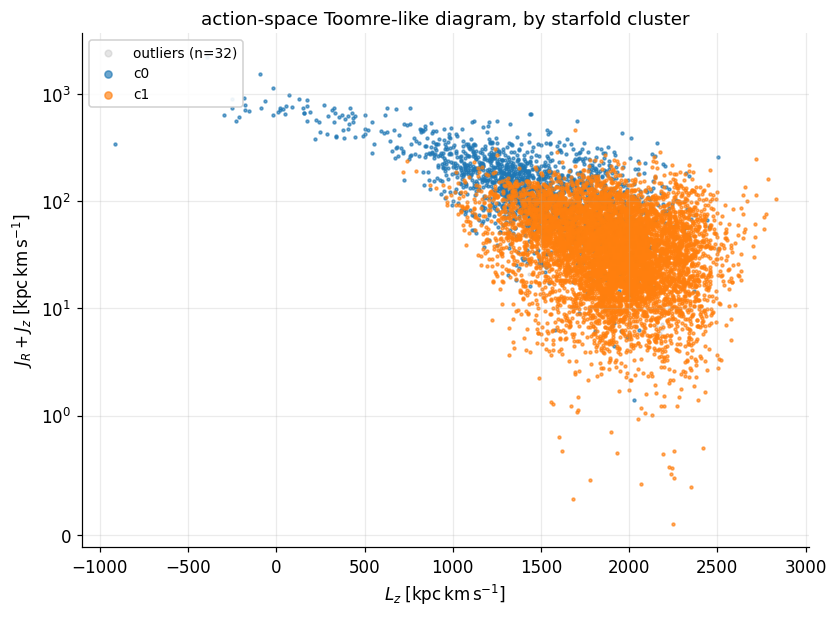

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
j_nc = sample["J_R"].to_numpy() + sample["J_z"].to_numpy()
ax.scatter(
    sample.loc[out, "L_z"], j_nc[out],
    c=OUTLIER_COLOUR, s=3.0, alpha=0.4,
    label=f"outliers (n={int(out.sum())})", rasterized=True,
)
for i, lab in enumerate(uniq):
    lab_mask = result.labels == lab
    ax.scatter(
        sample.loc[lab_mask, "L_z"], j_nc[lab_mask],
        s=3.5, alpha=0.65, color=cmap(i),
        label=f"c{lab}", rasterized=True,
    )
ax.set_yscale("symlog", linthresh=1.0)
ax.set_xlabel(LATEX_LABELS["L_z"])
ax.set_ylabel(r"$J_R + J_z\;[\mathrm{kpc\,km\,s^{-1}}]$")
ax.set_title(r"action-space Toomre-like diagram, by starfold cluster")
ax.legend(markerscale=2.5, loc="upper left", framealpha=0.9)
fig.savefig(FIGURE_DIR / "astro_toomre.png")
plt.show()

## 9. Per-feature distributions by cluster

Violin plots for every one of the eight input features, broken down by
HDBSCAN cluster. This is the "where does each cluster live in each
dimension" picture -- every feature on the same page, median marked,
outlier population in grey for reference. Gaussian kinematic actions
are shown on a `symlog` x-axis because their natural range spans several
orders of magnitude and the canonical disk/halo split is set by the
tails, not the core.

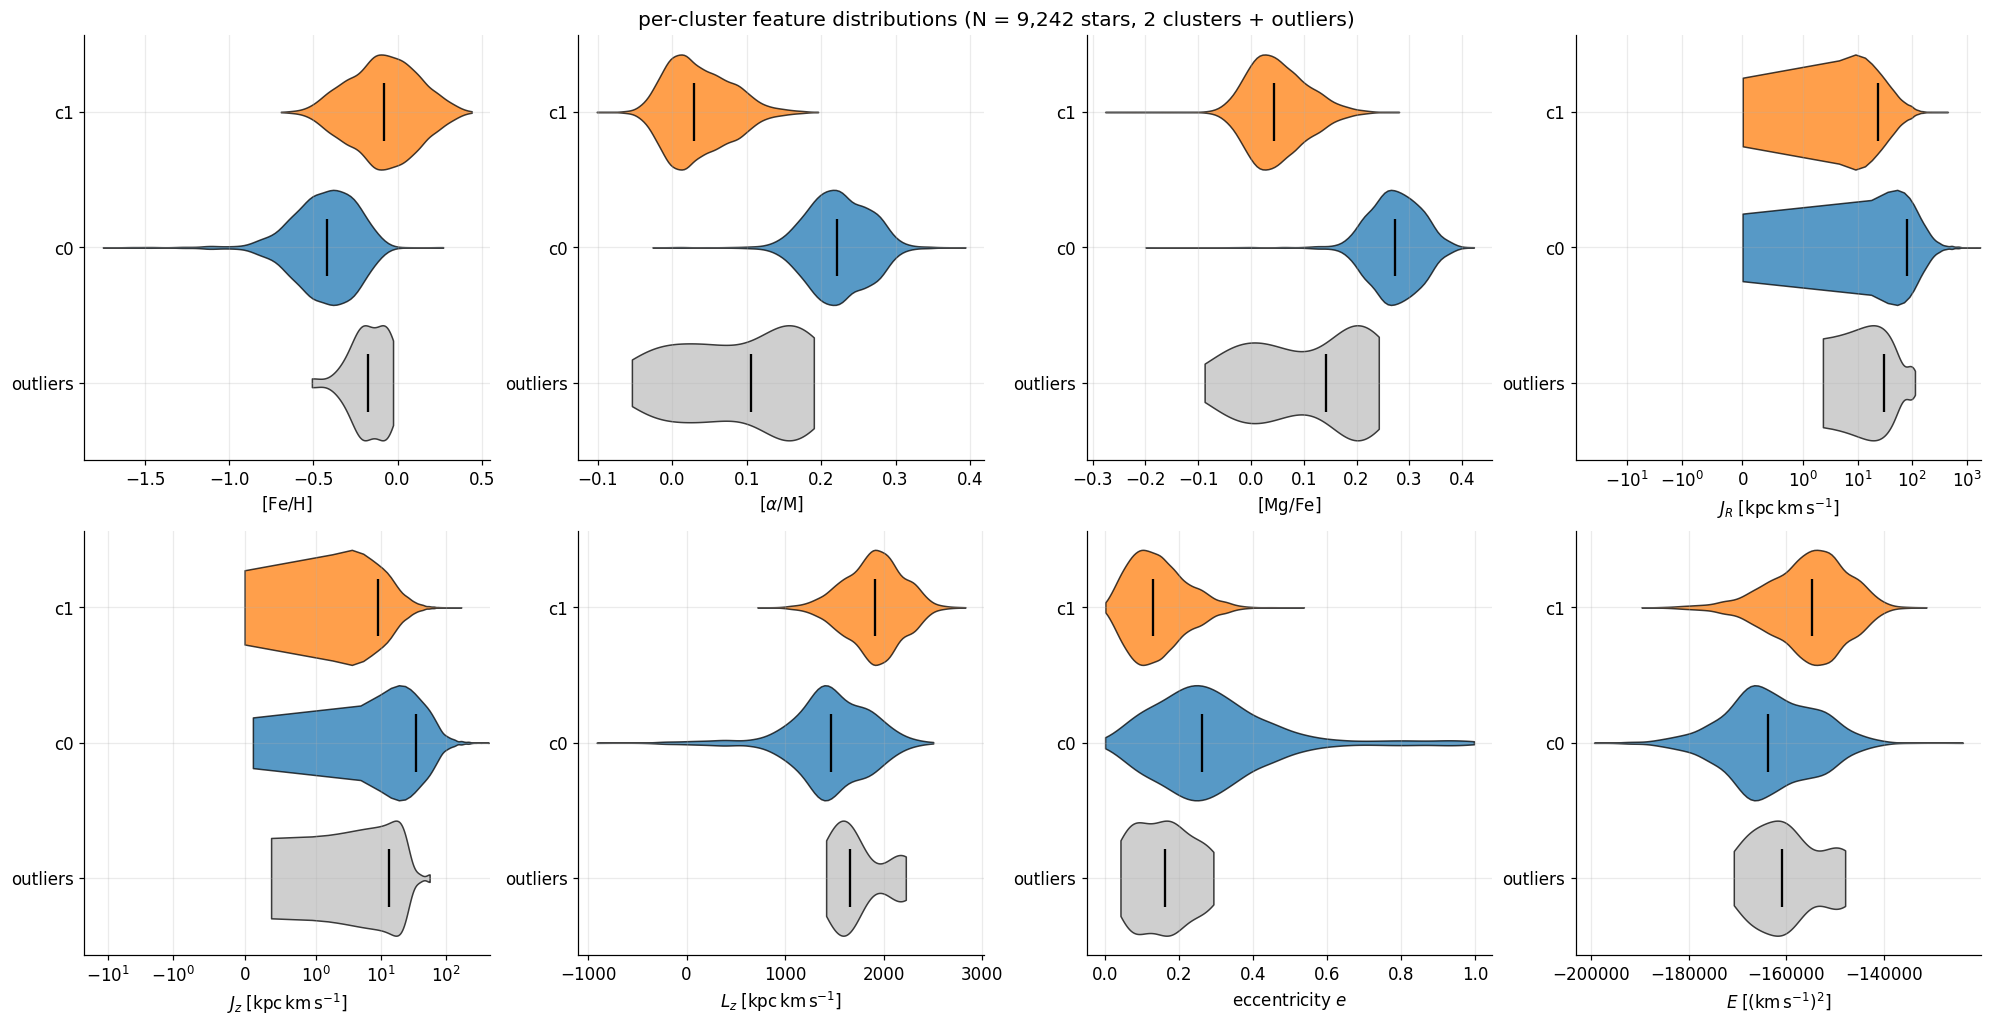

In [10]:
LOG_FEATURES = {"J_R", "J_z"}

cluster_ids = [int(lab) for lab in np.unique(result.labels) if lab != -1]
group_order = [
    ("outliers", sample.loc[result.labels == -1]),
    *(
        (f"c{lab}", sample.loc[result.labels == lab])
        for lab in cluster_ids
    ),
]
palette = [
    OUTLIER_COLOUR,
    *[plt.get_cmap(CLUSTER_CMAP_NAME)(i) for i in range(len(cluster_ids))],
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
for ax, feat in zip(axes.flat, FEATURES, strict=True):
    data = [g[feat].to_numpy() for _, g in group_order]
    positions = np.arange(len(group_order))
    parts = ax.violinplot(
        data, positions=positions, vert=False, showmedians=True,
        widths=0.85, showextrema=False,
    )
    for body, colour in zip(parts["bodies"], palette, strict=True):
        body.set_facecolor(colour)
        body.set_edgecolor("black")
        body.set_alpha(0.75)
    parts["cmedians"].set_color("black")
    ax.set_yticks(positions, [name for name, _ in group_order])
    ax.set_xlabel(LATEX_LABELS[feat])
    ax.grid(axis="x", alpha=0.25)
    if feat in LOG_FEATURES:
        ax.set_xscale("symlog", linthresh=1.0)
fig.suptitle(
    f"per-cluster feature distributions (N = {len(X):,} stars, "
    f"{len(cluster_ids)} clusters + outliers)",
    y=1.02,
)
fig.savefig(FIGURE_DIR / "astro_feature_violins.png")
plt.show()

## 10. Chemistry x kinematics scatter grid

A 3 x 3 grid of the diagnostic 2-D projections: each chemistry axis
(`[Fe/H]`, `[Mg/Fe]`, `[alpha/M]`) against each kinematic axis (`L_z`,
`E`, eccentricity), coloured by `starfold` cluster. Outliers are plotted
in grey underneath. This is the densest single view of "how do the
clusters separate in every relevant physical plane at once".

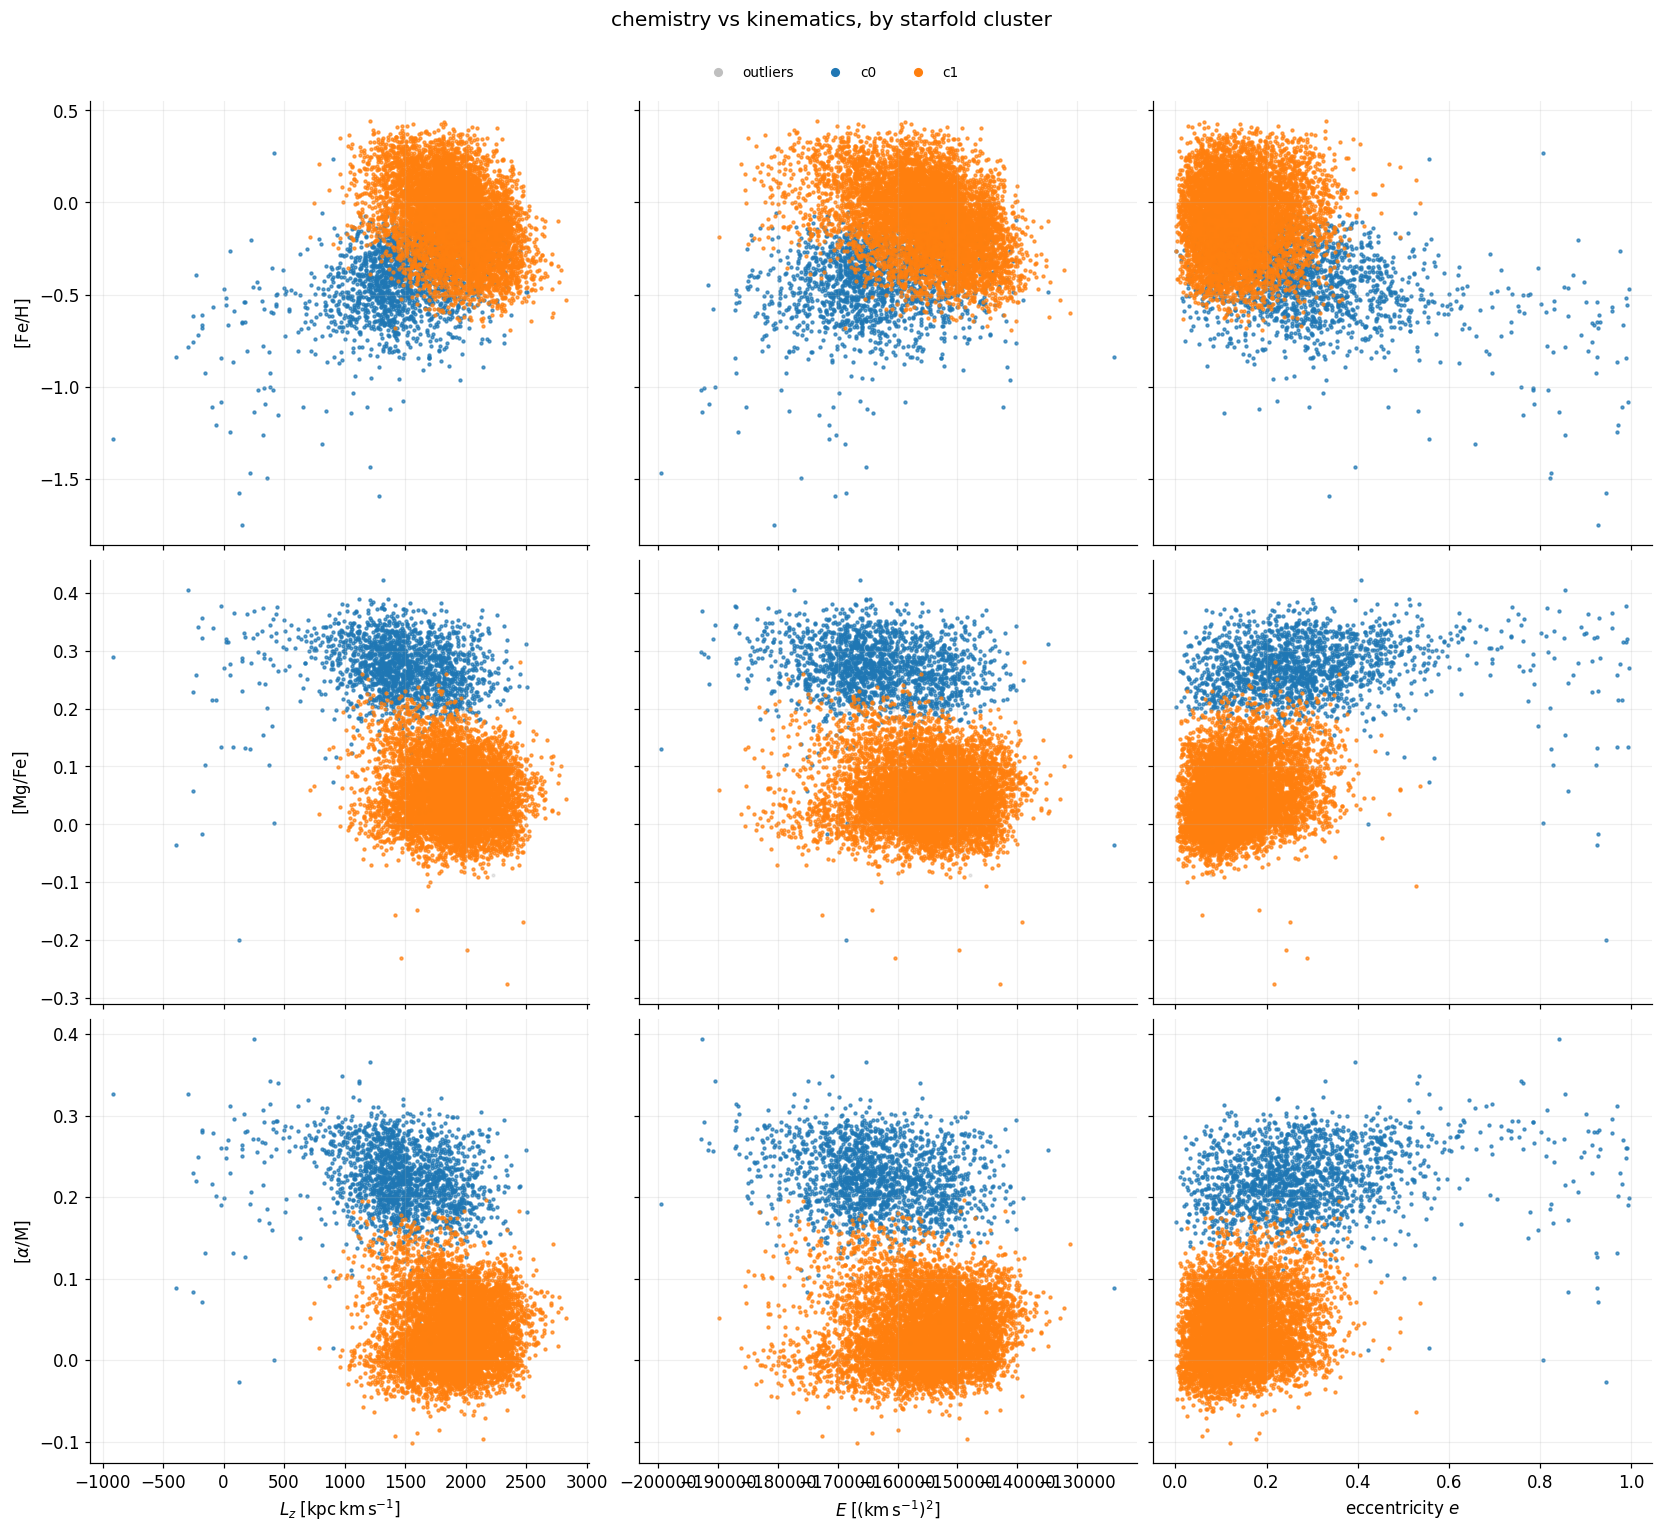

In [11]:
CHEM_AXES = ["fe_h", "mg_fe", "alpha_m"]
KIN_AXES = ["L_z", "E", "ecc"]

out_mask = result.labels == -1
cluster_colours = {
    lab: plt.get_cmap(CLUSTER_CMAP_NAME)(i)
    for i, lab in enumerate(cluster_ids)
}

fig, axes = plt.subplots(
    len(CHEM_AXES), len(KIN_AXES), figsize=(15, 13),
    sharex="col", sharey="row", constrained_layout=True,
)
for row, cy in enumerate(CHEM_AXES):
    for col, kx in enumerate(KIN_AXES):
        ax = axes[row, col]
        ax.scatter(
            sample.loc[out_mask, kx], sample.loc[out_mask, cy],
            c=OUTLIER_COLOUR, s=3.0, alpha=0.35, rasterized=True,
        )
        for lab, colour in cluster_colours.items():
            lab_mask = result.labels == lab
            ax.scatter(
                sample.loc[lab_mask, kx], sample.loc[lab_mask, cy],
                s=3.5, alpha=0.7, color=colour, rasterized=True,
            )
        if row == len(CHEM_AXES) - 1:
            ax.set_xlabel(LATEX_LABELS[kx])
        if col == 0:
            ax.set_ylabel(LATEX_LABELS[cy])
        ax.grid(alpha=0.2)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=OUTLIER_COLOUR, markersize=7, label="outliers"),
    *[
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=colour, markersize=7, label=f"c{lab}")
        for lab, colour in cluster_colours.items()
    ],
]
fig.legend(handles=legend_handles, loc="upper center",
           ncol=len(legend_handles), frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("chemistry vs kinematics, by starfold cluster", y=1.06)
fig.savefig(FIGURE_DIR / "astro_chem_kin_grid.png")
plt.show()

## 11. Trustworthiness curve

Trustworthiness `T(k)` measures how much of the `k`-nearest-neighbour
structure from the input space survives in the 2-D embedding. Reading
from left to right tells you whether UMAP preserves local structure
(small `k`) better than global (large `k`). The paper's acceptance
heuristic is `T(n_neighbors) > 0.90`.

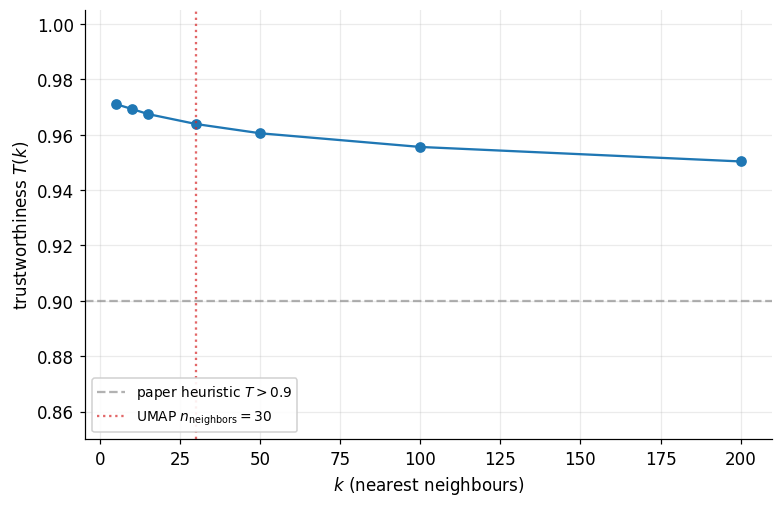

In [12]:
# trustworthiness_curve needs the *scaled* high-D input; the pipeline
# stashes the fitted scaler on the result, so we apply it here.
k_values = [5, 10, 15, 30, 50, 100, 200]
X_scaled = result.scaler.transform(X)
scores = sf.trustworthiness_curve(X_scaled, result.embedding, k_values=k_values)

fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)
sf.plot_trustworthiness_curve(scores, ax=ax, threshold=None)
ax.axhline(0.9, ls="--", color="grey", alpha=0.6,
           label=r"paper heuristic $T > 0.9$")
k_ref = int(fit_kwargs["umap_kwargs"]["n_neighbors"])
if k_ref in scores:
    ax.axvline(k_ref, ls=":", color="tab:red", alpha=0.7,
               label=fr"UMAP $n_{{\mathrm{{neighbors}}}} = {k_ref}$")
ax.set_xlabel(r"$k$ (nearest neighbours)")
ax.set_ylabel(r"trustworthiness $T(k)$")
ax.set_ylim(min(0.85, min(scores.values()) - 0.02), 1.005)
ax.legend(loc="lower left", framealpha=0.9)
fig.savefig(FIGURE_DIR / "astro_trust.png")
plt.show()

## 12. Overview dashboard

One figure, six panels: the headline view of a single `starfold` run
on this dataset. Top row shows the algorithm-side view (the UMAP
embedding coloured by cluster, plus the Optuna search and the
trustworthiness curve). Bottom row shows the physics-side view (chemical
abundances, action-space Toomre, per-cluster feature medians). This is
the figure to drop into a slide deck or a paper appendix.

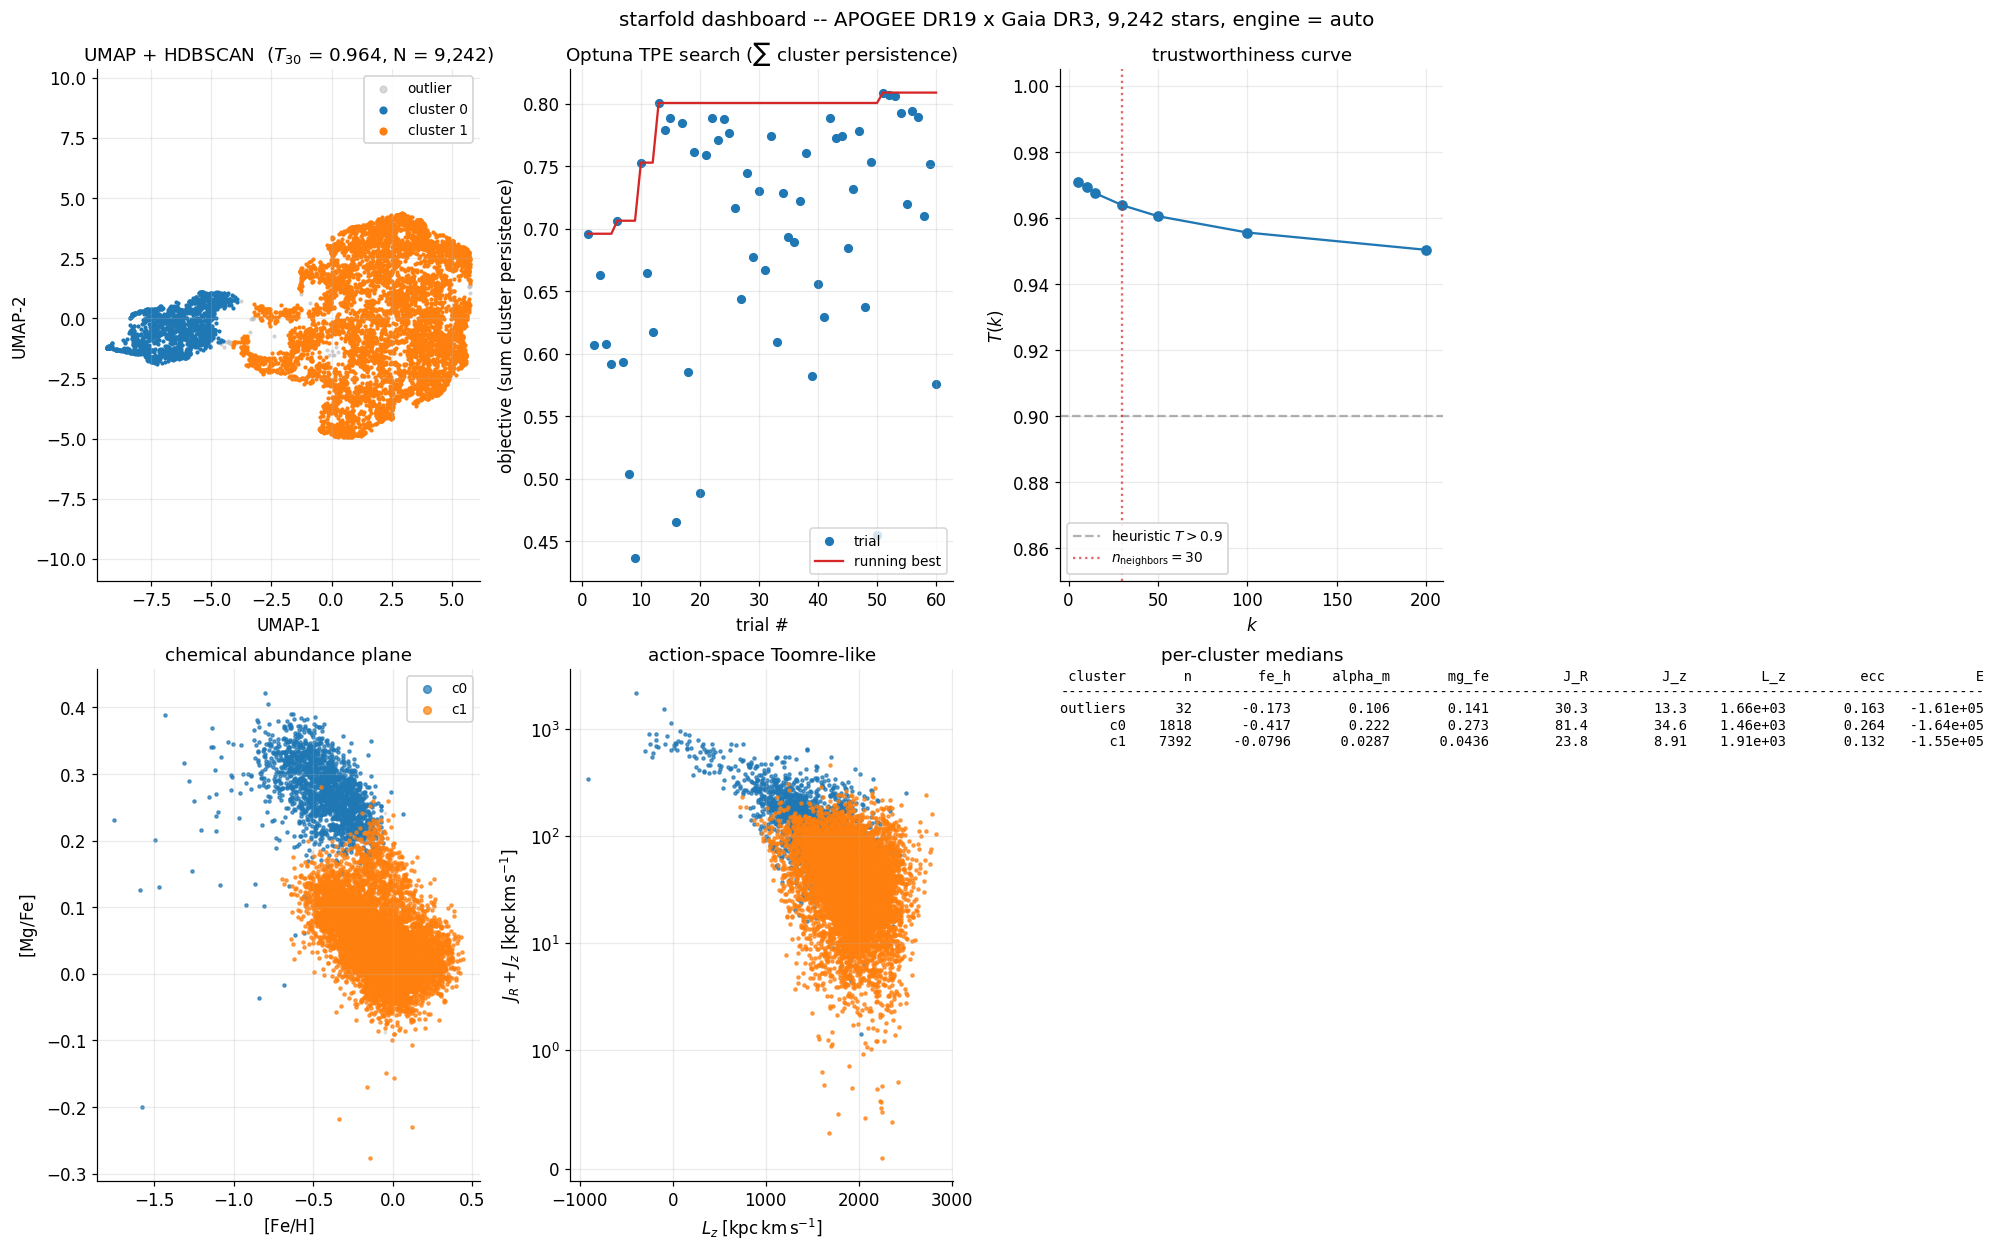

In [13]:
def _scatter_by_cluster(ax, x, y, *, x_label, y_label, title):
    out = result.labels == -1
    ax.scatter(
        x[out], y[out],
        c=OUTLIER_COLOUR, s=3.0, alpha=0.35, rasterized=True,
    )
    for lab in cluster_ids:
        m = result.labels == lab
        ax.scatter(
            x[m], y[m],
            s=4.0, alpha=0.7, color=cluster_colours[lab],
            label=f"c{lab}", rasterized=True,
        )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)


fig = plt.figure(figsize=(18, 11), constrained_layout=True)
gs = fig.add_gridspec(2, 3)
ax_emb   = fig.add_subplot(gs[0, 0])
ax_opt   = fig.add_subplot(gs[0, 1])
ax_trust = fig.add_subplot(gs[0, 2])
ax_chem  = fig.add_subplot(gs[1, 0])
ax_toom  = fig.add_subplot(gs[1, 1])
ax_sum   = fig.add_subplot(gs[1, 2])

sf.plot_embedding(
    result.embedding, result.labels,
    ax=ax_emb, point_size=3.0,
    outlier_color=OUTLIER_COLOUR, cmap=CLUSTER_CMAP_NAME,
)
ax_emb.set_xlabel("UMAP-1")
ax_emb.set_ylabel("UMAP-2")
ax_emb.set_title(
    f"UMAP + HDBSCAN  ($T_{{{k_ref}}}$ = {result.trustworthiness:.3f}, "
    f"N = {len(X):,})"
)
ax_emb.legend(loc="best", markerscale=2.5, framealpha=0.9)

sf.plot_optuna_history(result.search.study, ax=ax_opt)
ax_opt.set_title(r"Optuna TPE search ($\sum$ cluster persistence)")

ks = sorted(scores.keys())
ax_trust.plot(ks, [scores[k] for k in ks], marker="o", color="tab:blue")
ax_trust.axhline(0.9, ls="--", color="grey", alpha=0.6,
                 label=r"heuristic $T > 0.9$")
ax_trust.axvline(k_ref, ls=":", color="tab:red", alpha=0.7,
                 label=fr"$n_{{\mathrm{{neighbors}}}} = {k_ref}$")
ax_trust.set_xlabel(r"$k$")
ax_trust.set_ylabel(r"$T(k)$")
ax_trust.set_ylim(min(0.85, min(scores.values()) - 0.02), 1.005)
ax_trust.set_title("trustworthiness curve")
ax_trust.legend(loc="lower left", framealpha=0.9)

_scatter_by_cluster(
    ax_chem,
    sample["fe_h"].to_numpy(), sample["mg_fe"].to_numpy(),
    x_label=LATEX_LABELS["fe_h"], y_label=LATEX_LABELS["mg_fe"],
    title="chemical abundance plane",
)
ax_chem.legend(loc="upper right", markerscale=2.5, framealpha=0.9)

j_nc = sample["J_R"].to_numpy() + sample["J_z"].to_numpy()
_scatter_by_cluster(
    ax_toom,
    sample["L_z"].to_numpy(), j_nc,
    x_label=LATEX_LABELS["L_z"],
    y_label=r"$J_R + J_z\;[\mathrm{kpc\,km\,s^{-1}}]$",
    title="action-space Toomre-like",
)
ax_toom.set_yscale("symlog", linthresh=1.0)

# Summary text block (per-cluster medians). Plain-text monospace beats
# LaTeX here because column alignment matters more than typographic polish.
ax_sum.axis("off")
ax_sum.set_title("per-cluster medians")
header = f"{'cluster':>8s}  {'n':>6s}  " + "  ".join(f"{f:>10s}" for f in FEATURES)
rows = [header, "-" * len(header)]
for name, g in group_order:
    rows.append(
        f"{name:>8s}  {len(g):>6d}  "
        + "  ".join(f"{g[f].median():>10.3g}" for f in FEATURES)
    )
ax_sum.text(
    0.0, 1.0, "\n".join(rows),
    family="monospace", fontsize=9, va="top", ha="left",
    transform=ax_sum.transAxes,
)

fig.suptitle(
    f"starfold dashboard -- APOGEE DR19 x Gaia DR3, {len(X):,} stars, "
    f"engine = {result.config['engine']}",
    y=1.02, fontsize=13,
)
fig.savefig(FIGURE_DIR / "astro_dashboard.png")
plt.show()

## 13. Caveats

- The noise baseline is skipped here for speed. Set
  `skip_noise_baseline=False` and
  `noise_baseline_kwargs={"n_realisations": 1000}` to reproduce the
  paper's 3-sigma significance gate -- on a GPU that run is still
  measured in hours.
- The two-run workflow (re-cluster within each top-level component) is
  deliberately not baked into `starfold`; filter `X[result.labels == k]`
  and call `pipeline.fit` again. See `tutorial_01` for the snippet.
- This notebook does not attempt to interpret clusters as "thin disk",
  "thick disk", or "halo" -- that is domain knowledge, outside the scope
  of the package. The chemistry-plane, Toomre-like, violin, chemistry x
  kinematics, and dashboard panels are offered as *post-hoc* diagnostics,
  not part of starfold's output.
- `_cached_fit` stores the full `PipelineResult` (including the Optuna
  study) under `cache/astro_dr19/`. Re-running the notebook with the
  same `fit_kwargs` and `X` is nearly free; changing any argument
  invalidates the entry automatically. Wipe `cache/astro_dr19/` to
  force a fresh run.
- The bundled 9 242-star parquet is a temporary convenience for offline
  demos (APOGEE DR19 ASPCAP x Gaia DR3 kinematics). For scientific
  work, rebuild the feature table from the original surveys.